# Time Series Introduction

Author: Ethan Robert A. Casin<br>

---

Predicting the future has always been a keen interest of humans. From time immemorial, being able to predict events was a sign of divine inspiration. A gift from the gods. In ancient Babylon, forecasters would foretell the future based on the appearance of a sheep's liver. Around the same time, people would travel Delphi, Greece, to consult the Oracle who would provide her predictions while being intoxicated by ethylene vapors [1].

In modern times, forecasting is often seen in stock markets. Companies use them widely to create forecasts of their sales, informing them of what actions to take to meet such predictions. Predicting the future has always been this coveted skill by many and it's no wonder why. However, time series forecasting is no easy feat. 

For this lecture, we're going to learn some time series basics. This notebook is focused on providing basic concepts of time series analysis. The forecasting portion of this lecture will primarily be discussed in notebook `03B`, which is on ARIMA forecasting.

Think of this notebook as the introduction for us to understand ARIMA.

---

## Overview

In this notebook, students are expected to learn:
1. Definition of a time series
2. Random walk
3. Stationarity & Differencing
4. ARMA

---

In [33]:
!pip install scipy statsmodels --quiet

In [34]:
from typing import Union, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import scipy.stats as st # main library

# Defaults for plotting
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["figure.figsize"] = (15, 5)


# What is a time series?

A time series is a sequence of indexed values, where each value is an outcome of a random variable / proces. Essentially, it is one realization of a corresponding process. When we think of a time series we can simply think of it as anything that has been recorded over a period of time -- regularly or irregularly. 

Some examples are 
1. measuring students' attendance over time;
2. recording stock prices of a company;
3. recording a company's sales over time;

The goal in understanding time series data is to see if the observed patterns can help us forecast a period of time into the future. 



## Forecasting

Forecasting is predicting future values of our time series given all available information such as historical data and any other possible variables that can influence the data.

Considerations **before** forecasting a time series:
1. The kind of data (Trends, Seasonality, etc.)
2. Factors that influence the time series (Multivariates Analysis, Causality, etc.)
3. The amount of data available

# Stochastic Process

A stochastic or random process is a series of indexed random variables. In the context of time series, we'll use $t = 0, 1, 2, \dots n$ (discrete) time as an index. $\{\mathbf{X}_0, \mathbf{X}_1, \mathbf{X}_2, \dots \mathbf{X}_n \}$ denotes a process where $\mathbf{X}_t$ are random variables. 

We'll be seeing and discussing some examples of a time series generated from a stochastic process in the succeeding cells.

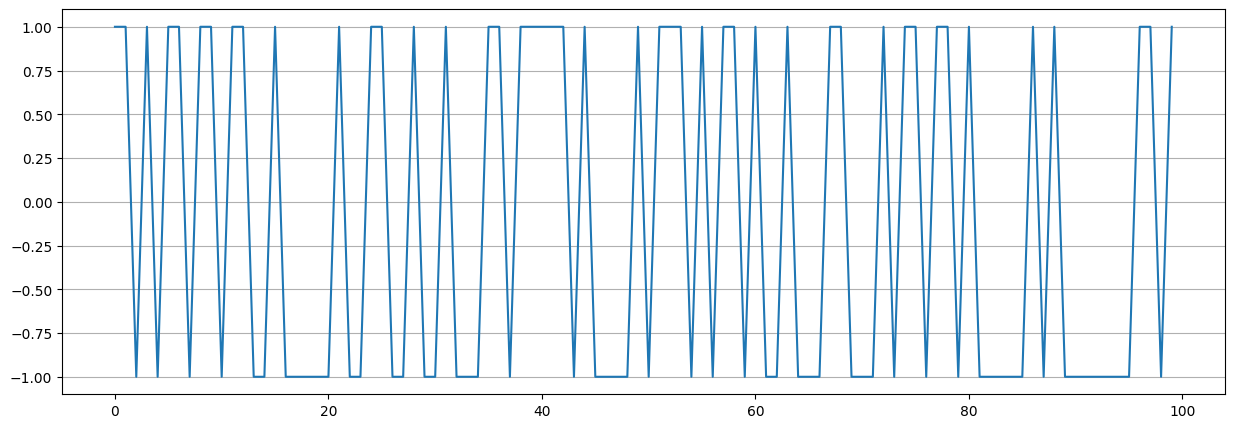

In [35]:
bernoulli_outcomes = [-1, 1]
n_trials = 100

np.random.seed(10)
random_selection = np.random.choice(bernoulli_outcomes, size=n_trials)

time_indices = range(n_trials)

plt.plot(time_indices, random_selection)

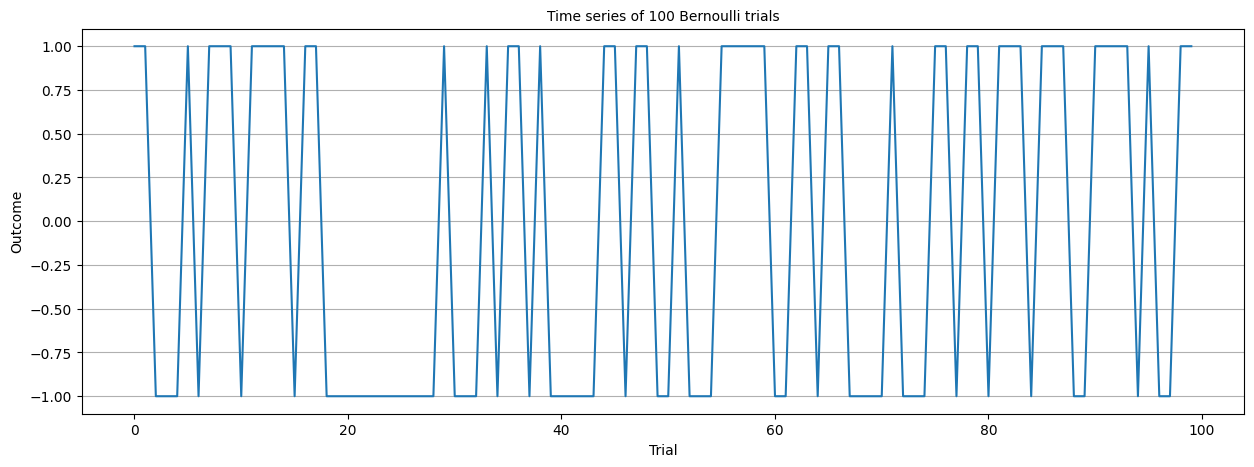

In [36]:
# Example 1: Bernoulli Trials
# A Bernoulli trial has two possible outcomes. For now, let's set it as {-1, 1}.
# -----------------------------------------------------------------------------

# Given the outcomes and the number of Bernoulli Trials
bernoulli_outcomes = [-1, 1]
n_trials = 100

# When you randomly select from the possible outcomes n times
np.random.seed(1441)
random_selection = np.random.choice(bernoulli_outcomes, size=n_trials)

# Then we can generate a time series from this stochastic process
time_indices = range(n_trials)  # we treat each trial as our time index

plt.plot(time_indices, random_selection)

plt.ylabel("Outcome")
plt.xlabel("Trial")
plt.title(f"Time series of {n_trials} Bernoulli trials", fontsize=10)
plt.show()

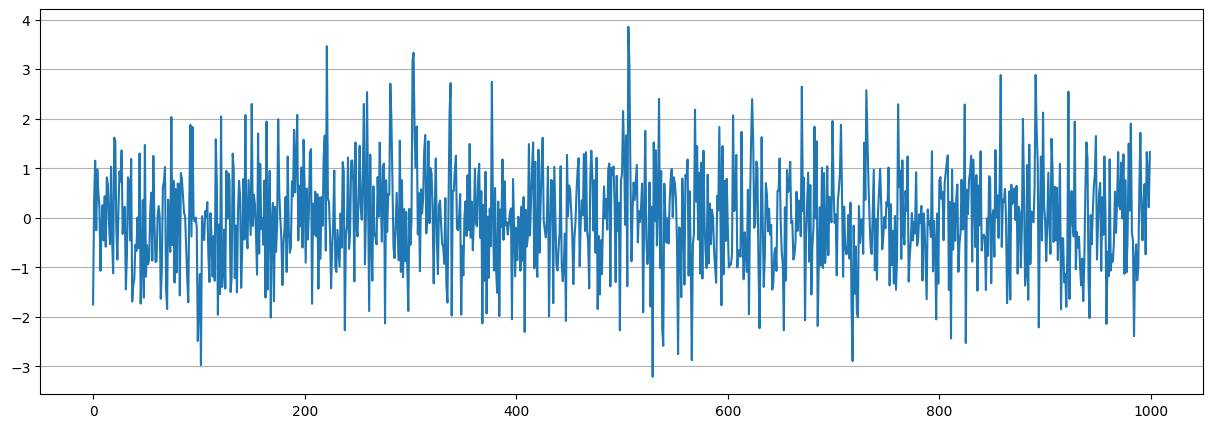

In [37]:
n_time_steps = 1000

np.random.seed(100)
gaussian_white_noise = np.random.normal(0, 1, size=n_time_steps)

time_indices = range(n_time_steps)

plt.plot(time_indices, gaussian_white_noise)

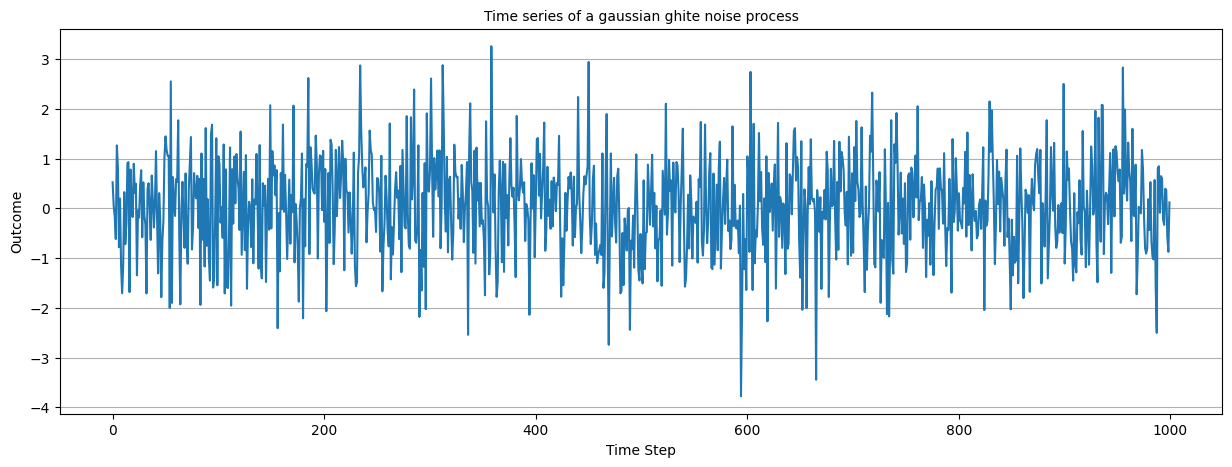

In [38]:
# Example 2: Gaussian White Noise (GWN)
# A GWN process generates a time series where each value was selected from a
# Gaussian distribution with zero mean and unit variance
# -----------------------------------------------------------------------------

# Given the number of time steps to record your process
n_time_steps = 1000

# When you get a random variable from a Gaussian distribution at each time step
np.random.seed(221)
gaussian_white_noise = np.random.normal(0, 1, size=n_time_steps)

# ------START ALTERNATE IMPLEMENTATION-------
# gaussian_white_noise = st.norm.rvs(size=n_time_steps)
# ------END ALTERNATE IMPLEMENTATION---------

# Then we can generate a time series from the GWN process
time_indices = range(n_time_steps)

plt.plot(time_indices, gaussian_white_noise)

plt.ylabel("Outcome")
plt.xlabel("Time Step")
plt.title(f"Time series of a gaussian ghite noise process", fontsize=10)
plt.show()

# Random Walk (Weiner Process)

A standard (one-dimensional) Weiner process, aka Brownian motion or random walk, is a stochastic process $\{W_t\}_{t\geq 0}$ that has the following properties:

1. **It always starts at $\mathbf{0}$**. Mathematically, $W_0 = 0$ such that $P(W_0 = 0) = 1$
2. **The Weiner process is continuous**. The function $W(t)$ is a continuous function in time $t$.
3. **It is memoryless**. This means that the change $W_{t + u} - W_t$, for $u \geq 0$, is independent of past values $W_s$, such that $s<t$.
4. **Each time interval (increment) is normally distributed**. Simply, this means that the the average value between two points is 0 and has a variance (or gap) of $\sigma^2$. More formally, $W_{t + u} - W_t \sim \mathcal{N}(0, \sigma^2)$

In a time series, the importance of the Weiner process is that it serves as a model for random movement over time. In recent years it has been used in finance for the [Black-Scholes model](https://en.wikipedia.org/wiki/Black–Scholes_model).

From property 4, we can reformulate our Weiner process in order to generate succeeding steps. Given that any time interval is drawn from a normal distribution we can then generate the Weiner process for $n$ points using

$$W_t = W_{t - 1} + \mathcal{N}(0, \sigma^2)$$

where each succeeding time step $t$ was generated randomly from a normal distribution. If we think about it, it is essentially a cumulative sum of a white noise time series or a random walker's displacement.

For convenience, we can rewrite this in terms of $y$ and $\epsilon$ thus

$$y_t = y_{t - 1} + \epsilon_t$$

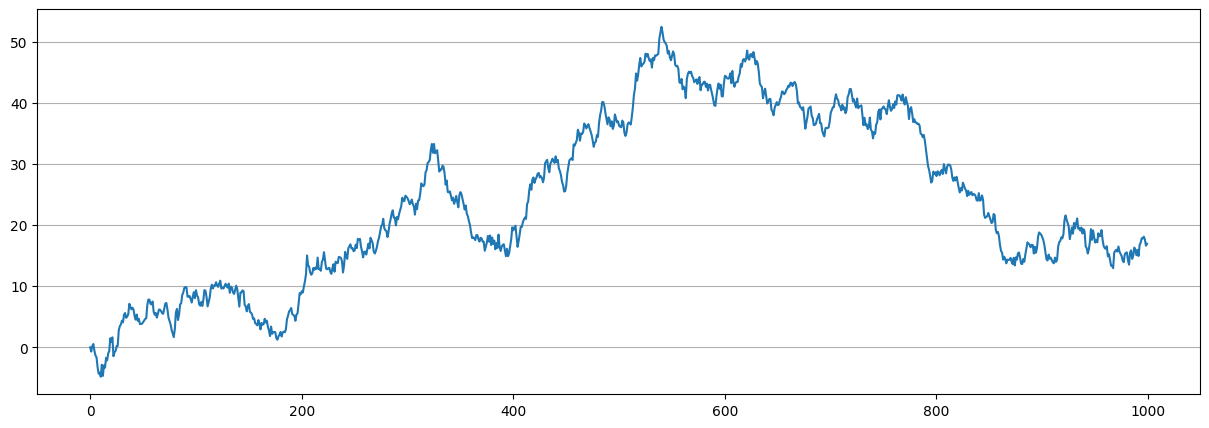

In [39]:
time_series_length = 1000
weiner_process = np.zeros(time_series_length)
variance = 1

random_values = np.random.normal(0, np.sqrt(variance), size=time_series_length - 1)
weiner_process[1:] = np.cumsum(random_values)

plt.plot(weiner_process)

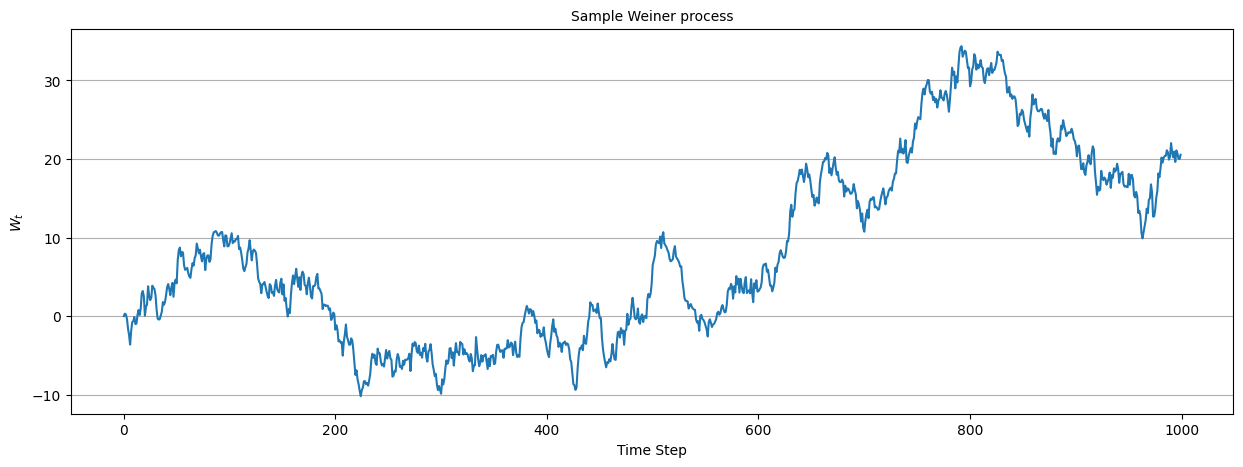

In [40]:
# Example 3: Modeling the Weiner process
# ------------------------------------------------------------------------------

# Given a length of the time series, variance (step size), and a starting point
time_series_length = 1000
weiner_process = np.zeros(time_series_length)
variance = 1  # This is sometimes defined as dt in other references

# When we generate all of the steps in a Weiner process
#np.random.seed(225)

for t in range(1, time_series_length):
    # Note that numpy uses the standard deviation not the variance
    weiner_process[t] = weiner_process[t - 1] + np.random.normal(0, np.sqrt(variance),)

# ------START ALTERNATE IMPLEMENTATION-------
# random_values = np.random.normal(0, np.sqrt(variance), size=time_series_length - 1)
# weiner_process[1:] = np.cumsum(random_values)
# ------END ALTERNATE IMPLEMENTATION---------

# Then we can plot out our Weiner process

plt.plot(weiner_process)

plt.xlabel("Time Step")
plt.ylabel("$W_t$")
plt.title("Sample Weiner process", fontsize=10)
plt.show()

In [41]:
def generate_weiner_process(n_points, variance, seed=None):
    np.random.seed(seed)

    weiner_process = np.zeros(n_points)
    standard_dev = np.sqrt(variance)

    random_values = np.random.normal(0, standard_dev, size=n_points - 1)
    weiner_process[1:] = np.cumsum(random_values)
    return weiner_process

In [42]:
# Let's create a function for our Weiner process for convenience
def generate_weiner_process(
    n_points: int,
    variance: Union[float, int],
    seed: Optional[int] = None,
) -> np.ndarray[float]:
    """Generate a random Weiner process.

    Parameters:
    ----------
    n_points (int): Length of the time series to create
    variance (float, int): The variance to use in generating the process
    seed (int): Random seed to set for reproducibility. Set to 'None' if you
        intend on making multiple Weiner processes

    Returns:
    --------
    ndarray: The completed Weiner process.
    """

    np.random.seed(seed)

    weiner_process = np.zeros(n_points)
    standard_dev = np.sqrt(variance)

    random_values = np.random.normal(0, standard_dev, size=n_points - 1)
    weiner_process[1:] = np.cumsum(random_values)
    return weiner_process

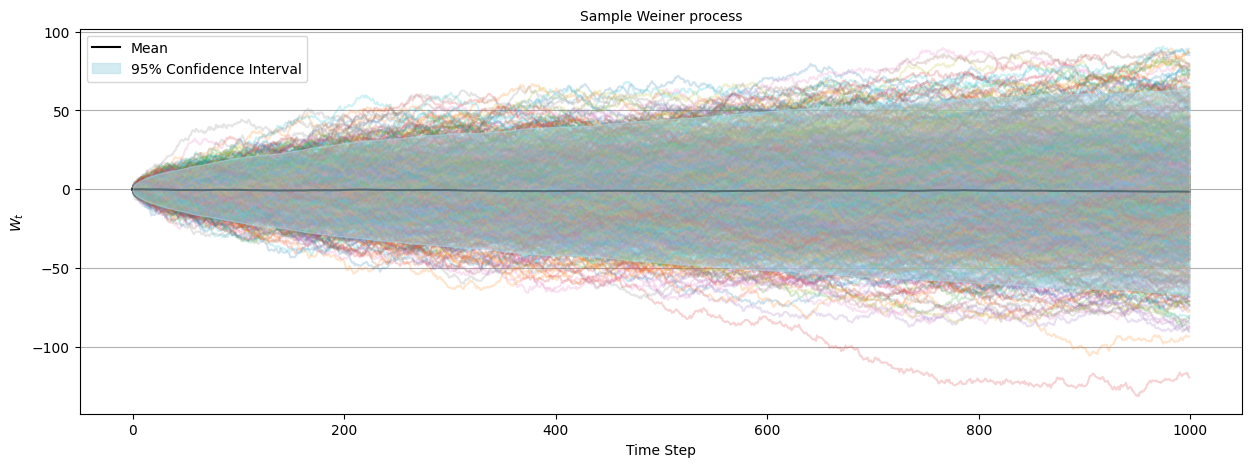

In [43]:
# Example 4: Modeling multiple Weiner processes
# ------------------------------------------------------------------------------

# Given a length of the time series, variance (step size), and the number of iterations
time_series_length = 1000
variance = 1  # This is sometimes defined as dt in other references
n_iterations = 1000

# When we create multiple Weiner Processes
all_weiner = np.array(
    [generate_weiner_process(time_series_length, variance) for _ in range(n_iterations)]
)

# Then we can plot out a confidence interval from our processes
mean = np.mean(all_weiner, axis=0)
standard_dev = np.std(all_weiner, axis=0)

plt.figure(figsize=(15, 5))
for process in all_weiner:
    plt.plot(process, alpha=0.2)

plt.plot(mean, color="black", label="Mean")
plt.fill_between(
    range(time_series_length),
    mean - 2 * standard_dev,
    mean + 2 * standard_dev,
    color="lightblue",
    alpha=0.5,
    label="95% Confidence Interval",
    zorder=10,
)

plt.xlabel("Time Step")
plt.ylabel("$W_t$")
plt.title("Sample Weiner process", fontsize=10)
plt.legend()
plt.show()

A Weiner process may not always have a zero mean. In this case a Weiner process with a non-zero mean $\mu$ is called a random walk with **drift**. In terms of $y_t$ it can be defined as

$$y_t = \mu + y_{t-1} + \epsilon_t,$$

where $\mu$ is the average of the changes between consecutive observations and $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$ is the white noise or error term. If $\mu > 0$, then the time series will drift **upwards**. Conversely, when $\mu < 0$ the time series will drift **downards**. 

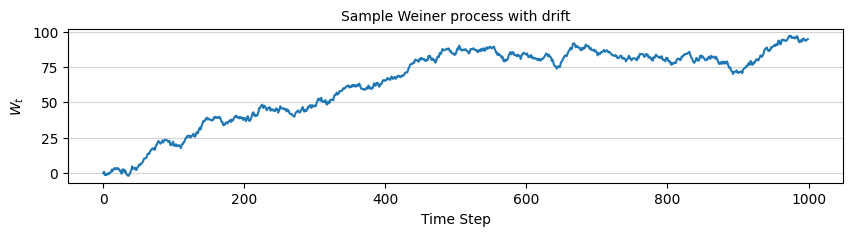

In [44]:
# Example 5: Modeling the Weiner process with drift
# ------------------------------------------------------------------------------

# Given a length of the time series, variance (step size), and a non-zero mean
time_series_length = 1000
weiner_process = np.zeros(time_series_length)
variance = 1  # This is sometimes defined as dt in other references
mu = 0.1  # drift term

# When we generate all of the steps in a Weiner process with a non-zero mean
for t in range(1, time_series_length):
    # Note that numpy uses the standard deviation not the variance
    white_noise = np.random.normal(0, np.sqrt(variance))
    weiner_process[t] = weiner_process[t - 1] + mu + white_noise

# ------START ALTERNATE IMPLEMENTATION-------
# random_values = np.random.normal(0, np.sqrt(variance), size=time_series_length - 1)
# weiner_process[1:] = np.cumsum(random_values + mu)
# ------END ALTERNATE IMPLEMENTATION---------

# Then we can plot out our Weiner process with drift

plt.figure(figsize=(10, 2))
plt.plot(weiner_process)

plt.xlabel("Time Step")
plt.ylabel("$W_t$")
plt.title("Sample Weiner process with drift", fontsize=10)
plt.grid(axis="y", c="lightgray")
plt.show()

In [45]:
def generate_drift_weiner_process(n_points, variance, mean, seed=None):
    np.random.seed(seed)

    weiner_process = np.zeros(n_points)
    standard_dev = np.sqrt(variance)

    random_values = np.random.normal(0, standard_dev, size=n_points - 1)
    weiner_process[1:] = np.cumsum(random_values + mean)

    return weiner_process

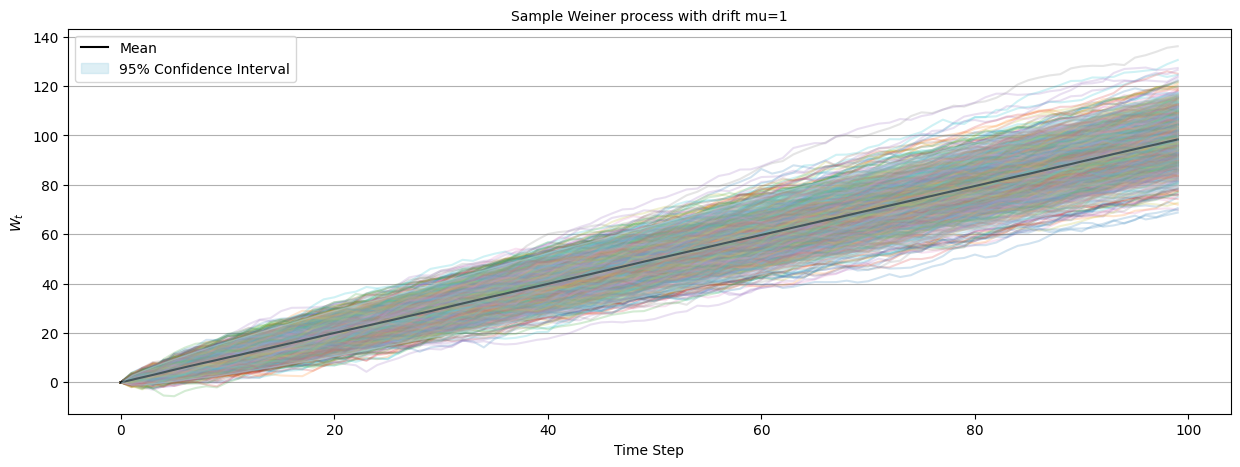

In [46]:
time_series_length = 100
variance = 1
n_iterations = 1000
mu = 1
all_drift_weiners = np.array(
    [generate_drift_weiner_process(time_series_length, variance, mu) for _ in range(n_iterations)]
)

mean = np.mean(all_drift_weiners, axis=0)
standard_dev = np.std(all_drift_weiners, axis=0)

plt.figure(figsize=(15, 5))
for process in all_drift_weiners:
    plt.plot(process, alpha=0.2)

plt.plot(mean, color='black', label='Mean')
plt.fill_between(
    range(time_series_length),
    mean - 2 * standard_dev,
    mean + 2 * standard_dev,
    color='lightblue',
    alpha=0.4,
    label='95% Confidence Interval',
    zorder=10,
)

plt.xlabel("Time Step")
plt.ylabel("$W_t$")
plt.title(f"Sample Weiner process with drift mu={mu}", fontsize=10)
plt.legend()
plt.show()

# Stationarity & Differencing

In the following section, we will talk about ARMA. However, we will be discussing it from the ground up, starting from the stationary process, to individual components, until it's formal definition.

A stationary time series is one whose statistical properties do not depend on the time at which the series was observed. Therefore, time series with trends or seasonality are non-stationary as these would affect the value of time series at different times. This implies that a stationary time would be roughly horizontal with no predictable patterns in the long-term. So no matter where you observe it, a stationary time series should look pretty much the same at any point in time.



---

**Question** Which among these do you think are stationary?

<figure>
    <img src="figures/stationarity.png" width="800px"></img>
    <figcaption>Image retrieved from <a href="https://otexts.com/fpp3/stationarity.html">here.</a></figcaption>
</figure>

---

In [47]:
from statsmodels.graphics.tsaplots import plot_acf

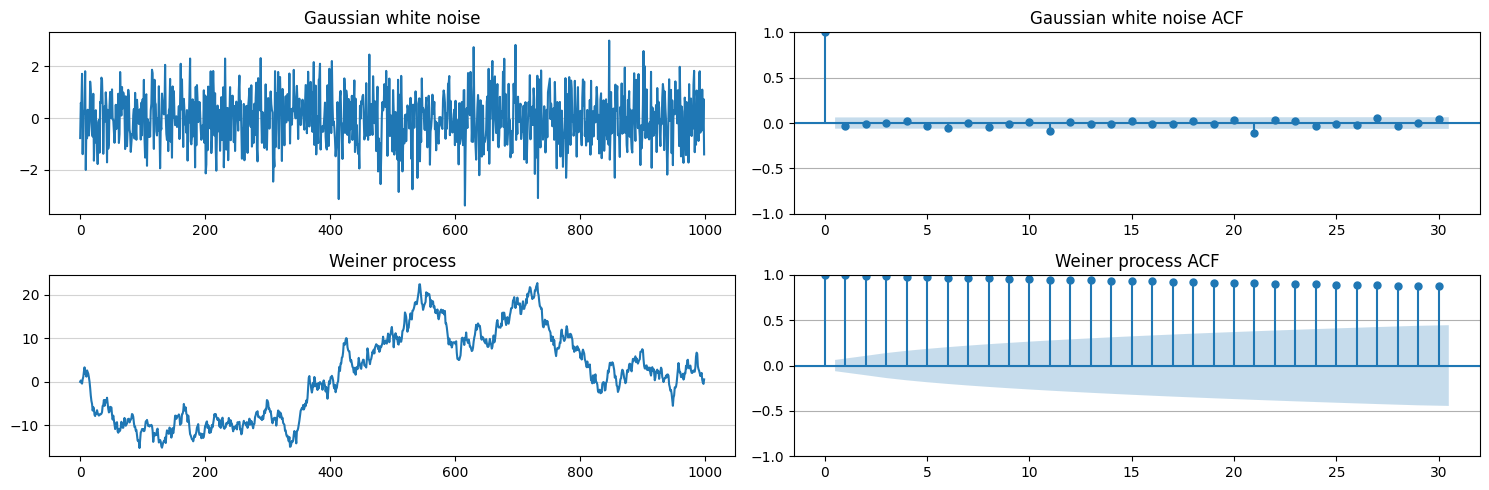

In [48]:
# Example 6: Are Gaussian White Noise and a Random Walk stationary?
# ------------------------------------------------------------------------------

# Given a number of time steps
n_time_steps = 1000

# When we create GWN and random walk time series
white_noise = np.random.normal(0, 1, size=n_time_steps)
random_walk = generate_weiner_process(n_time_steps, 1)

# Then we can inspect their stationarity using an ACF plot
fig, ax = plt.subplots(2, 2, figsize=(15, 5))

time_series_collection = [white_noise, random_walk]
series_names = ["Gaussian white noise", "Weiner process"]
for i, series in enumerate(time_series_collection):
    ax[i % 2, 0].plot(series)
    ax[i % 2, 0].set_title(series_names[i])
    ax[i % 2, 0].grid(axis="y", c="lightgray")

    plot_acf(series, ax=ax[i % 2, 1], title=f"{series_names[i]} ACF")

plt.tight_layout()

A characteristic of a stationary time series is that when observing it's ACF plot, we can see that it suddenly drops to 0. Whereas it would drop slowly if it is a non-stationary time series. We can see from the plots that Gaussian white noise is a stationary time series. However it should be noted that the inverse is not always true, i.e., a stationary time series may not be Gaussian white noise. This is often a misconception about stationary time series in practice. 

A stationary time series has a couple of mathematical properties.

**It is invariant to time-translation**. Consider a process $\{X_t \}$, with a corresponding joint distribution $P(X_{t_1 + \tau} , \dots , X_{t_n + \tau})$ at times $t_1 + \tau, \dots, t_n + \tau$ is stationary if

$$P(X_{t_1 + \tau} , \dots , X_{t_n + \tau}) = P(X_{t_1} , \dots , X_{t_n})$$

This definition is quite strict and there's a more lenient version of this called *weakly stationary*

#### Weakly Stationary

The process $\{X_t\}$ is *weakly* stationary if:
1. **The means are constant**. $\mu(X_t) = \mu(X_{t + \tau})$;
2. **The autocovariance depends only on $\tau$, which means that the variability between $X_t$ and $X_{t + \tau}$ are the same (the standard deviation is constant)**. $\Gamma(t_1, t_2) = \Gamma(t_2 - t_1) = \Gamma(\tau)$, where $\Gamma(\cdot)$ is the autocovariance function; and
3. **The second moments (variance) is finite for any time $t$**. $E[X_t^2] < \infty$.

## Autocorrelation

A very useful concept to know about time series analysis is **autocorrelation**. Much like typical correlation, autocorrelation measures the linear relationship between *lagged* values of a time series.

---

**Question**: Why should we measure the correlation of a time series of itself? Any practical reasons?

---

In general, the **autocorrelation** of a time series has the form

\begin{align*}
r_k = \frac{\sum_{t=k+1}^T(y_t - \bar{y})(y_{t - k} - \bar{y})}{\sum_{t=1}^T(y_t - \bar{y})^2},
\end{align*}

where $T$ is the length of the time series $y$, $r_k$ is the sample autocorrelation coefficient at lag $k$. The autocorrelation coefficients at various $k$ make up the *autocorrelation function* or ACF.

To make it more interpretable, 
- $r_1$ measures the relationship between $y_t$ and its previous value $y_{t-1}$ (succeeding values)
- $r_2$ measures the relationship between $y_t$ and $y_{t-2}$ (two periods apart)


We usually plot the ACF to see how the correlations change with lag $k$, This plot is called the ACF plot or correlogram.

In [49]:
import statsmodels.api as sm

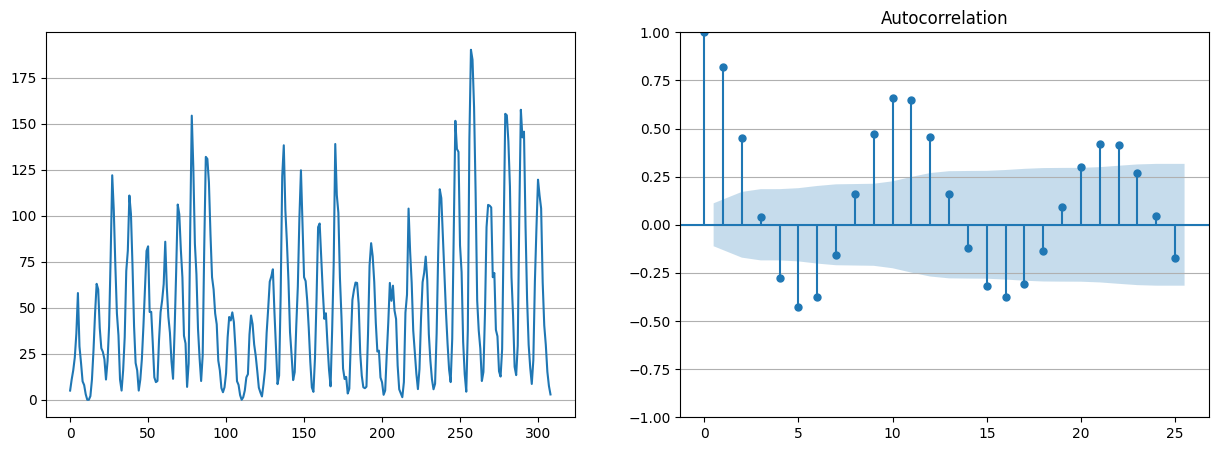

In [50]:
sunspots_data = sm.datasets.sunspots.load_pandas().data

fig, ax = plt.subplots(1, 2)

ax[0].plot(sunspots_data["SUNACTIVITY"])
plot_acf(sunspots_data["SUNACTIVITY"], ax=ax[1])

plt.show()

## Partial Autocorrelation

One of the quirks of ACF is that it is implicitly trying to persist some correlation from previous time steps to the current time step we have. For this reason, **ACF tends to include both direct and indirect** relationships. There are many cases where you would only want to measure **direct** relationships between time steps. With this, we can use a **partial** version of ACF, known as **PACF**.

In contrast to ACF, **PACF only measures the direct relationships** between time steps. We intuitively do this by measuring the correlation of the time series with itself and removing any effects of intermediary lags. 

PACF can be illustrated as

\begin{align*}
\rho_{XY} = \frac{\rho_{XY} - \rho_{XZ}\rho_{YZ}}{\sqrt{(1 - \rho_{XZ}^2)(1-\rho_{YZ}^2)}},
\end{align*}

where $\rho_{XY}$ is the direct correlation of $X$ and $Y$ time steps, $\rho_{XZ}$ is the correlation between $X$ and $Z$, and $\rho_{YZ}$ is the correlation between $Y$ and $Z$. The numerator represents the correlation between $X$ and $Y$ after accounting for the intermediary effects $Z$ between them, while the denominator normalizes the correlation by removing the effects of $Z$. 

In [51]:
from statsmodels.graphics.tsaplots import plot_pacf

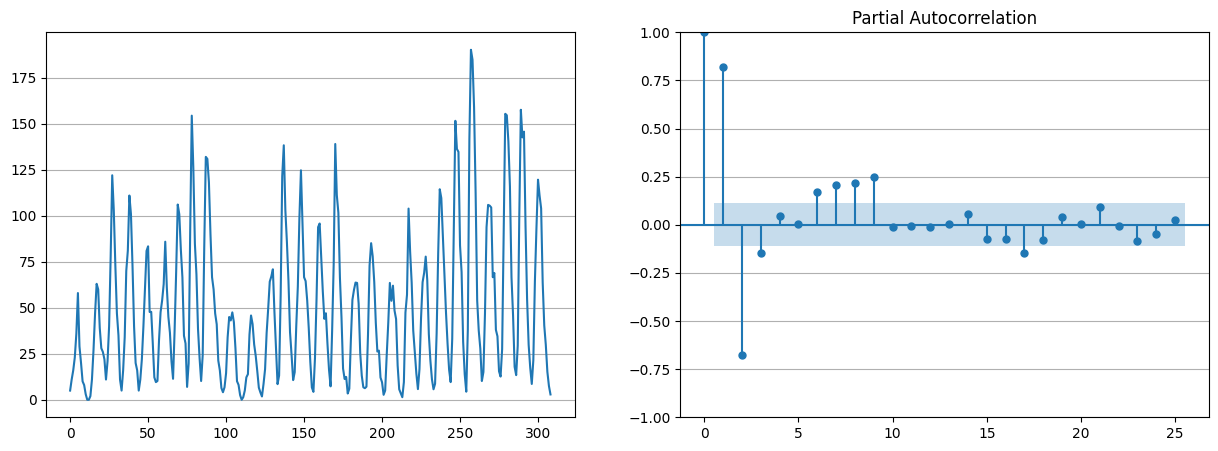

In [52]:
fig, ax = plt.subplots(1, 2)

ax[0].plot(sunspots_data["SUNACTIVITY"])
plot_pacf(sunspots_data["SUNACTIVITY"], ax=ax[1])

plt.show()

## Stationarity Tests

We have two standard statistical tests for us to check for stationarity. These are 1) Augmented Dickey-Fuller Test (ADF Test) and the 2) Kwiatkowski-Phillips-Schmidt-Shin Test (KPSS Test).

These two tests go hand-in-hand and they tell you wether or not a time series is stationary. These are the null hypothesis for both tests and what your desired result should be.

| Test | $H_0$ | Desired Outcome | Null Hypothesis |
| ---  | ----  |  -------------  | ------ |
| ADF Test | Time series has at least 1 unit root | Reject $H_0$ | Non-stationary and non-seasonal |
| KPSS Test | Time series has no unit root | Accept $H_0$ | stationary and non-seasonal |

In [53]:
from statsmodels.tsa.stattools import adfuller, kpss

In [54]:
p_value = 0.05

adf_res = adfuller(sunspots_data["SUNACTIVITY"])
adf_pval = adf_res[1]
print(f"P-Value: {adf_pval:.4f}")
print("Stationary" if adf_pval < p_value else "Not Stationary")

P-Value: 0.0531
Not Stationary


In [17]:
p_value = 0.05

kpss_res = kpss(sunspots_data["SUNACTIVITY"])
kpss_pval = kpss_res[1]
print(f"P-Value: {kpss_pval:.4f}")
print("Not Stationary" if kpss_pval < p_value else "Stationary")

P-Value: 0.0163
Not Stationary


In general, you may need to do multiple rounds of differencing to make the time series stationary. More on that in the next section.

You may already be wondering right now, what is a unit root. Later, we will discuss what it is and why it's an important concept to learn for time series.

When using these two tests, you would run into different configurations of results. To help guide you, here are some interpretations of certain combinations from these two tests:

| ADF Test | KPSS Test | Interpretation | Remedy |
| -------- | --------- | -------------- | ------ |
| Stationary | Stationary | Time series is stationary | None |
| Not stationary | Not stationary | Time series is not stationary | Preprocess |
| Not stationary | Stationary | Trend stationary | Detrend (not discussed) |
| Stationary | Not stationary | Difference stationary | Difference the time series |


## Differencing

The goal of differencing is to make a non-stationary time series stationary. This is done by computing the differences between consecutive observations. Moreover, differencing can help stabilize the mean of a time series by removing changes in the level of a time series. Doing this, we could expect that we reduce (or eliminate) the effects of the trend and seasonality. 


**First-order Differencing**

A first-order difference can be written as

$$y_t' = y_t - y_{t-1}$$

Note that $y_t'$ would only be $T - 1$ long, since it is impossible to compute a difference for the first observation. If the resulting differenced time series is white noise, we can rewrite the equation as

$$y_t - y_{t - 1} = \epsilon_t$$

where $\epsilon_t$ is white noise. This leads the model to be the Weiner process or random walk.

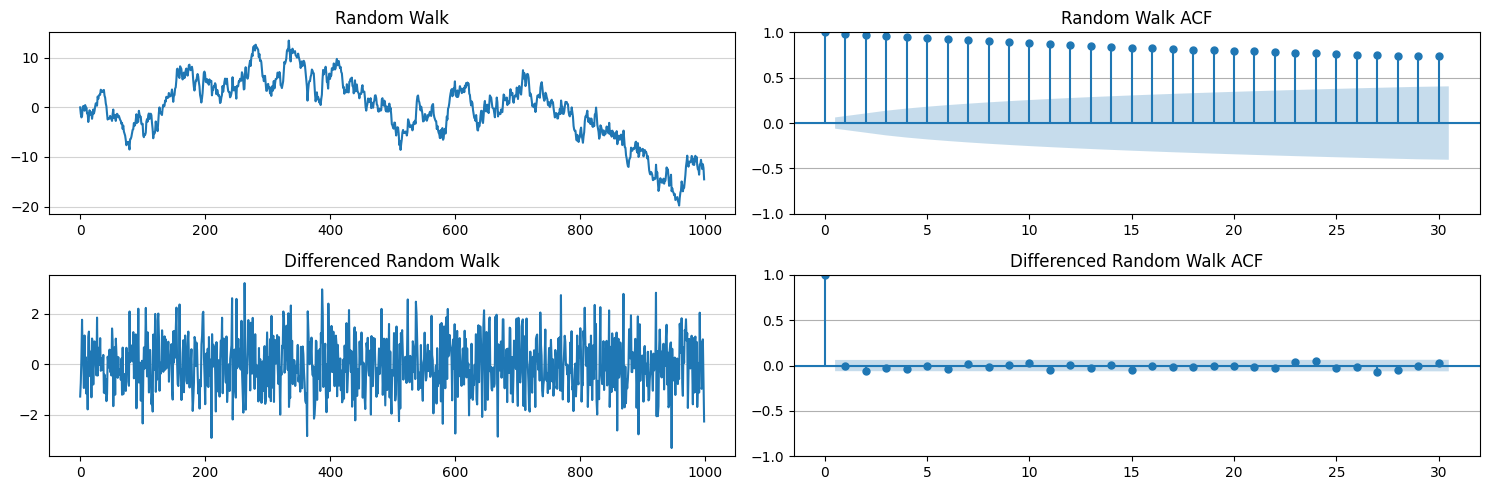

In [18]:
# Example 7: Differencing a random walk
# Let's revisit our previous result and check if differencing it would
# make it stationary
# ------------------------------------------------------------------------------

# Given a random walk process
n_time_steps = 1000
random_walk = generate_weiner_process(n_time_steps, 1)

# When we take its first-order difference
first_order_diff = np.diff(random_walk)

# Then we can find that the stationary series is Gaussian white noise
fig, ax = plt.subplots(2, 2, figsize=(15, 5))

time_series_collection = [random_walk, first_order_diff]
series_names = ["Random Walk", "Differenced Random Walk"]
for i, series in enumerate(time_series_collection):
    ax[i % 2, 0].plot(series)
    ax[i % 2, 0].set_title(series_names[i])
    ax[i % 2, 0].grid(axis="y", c="lightgray")
    plot_acf(series, ax=ax[i % 2, 1], title=f"{series_names[i]} ACF")

plt.tight_layout()

As shown above, if the resulting stationary time series produces white noise then we could say that the time series is a random walk. 

**Second-order Differencing**

In certain cases, a first-order difference may not be enough. In these cases it might be helpful to do a second-order difference. A second-order difference $y_t''$ is defined as

\begin{align*}
    y_t''&= y_t' - y_{t-1}'\\
         &= (y_t - y_{t-1}) - (y_{t-1} - y_{t-2})\\
    y_t''&= y_t - 2y_{t-1} - y_{t-2}
\end{align*}

**Seasonal Differencing**

One common differencing method for seasonal time series is seasonal differencing. The main difference is that we conduct the differencing between the observation and the previous observation from the same period. For example, if we have a quarterly season, then we could conduct our differencing using either of the following: $t - 3$ (monthly) or $t - 90$ (daily) or some other variant. We can generalize this using the formulation 

$$y_t' = y_t - y_{t - m}$$

where $m$ is the number of seasonal periods. These are also called *lag-m differences*, because we subtract the observation after a lag $m$ periods. If the seasonally difference time series is equal to white noise, then the forecasts are equal to the last observation of the relevant period. This makes it equal to a seasonal naive forecast. 

Mathematically,

$$y_t - y_{t - m} = \epsilon_t$$



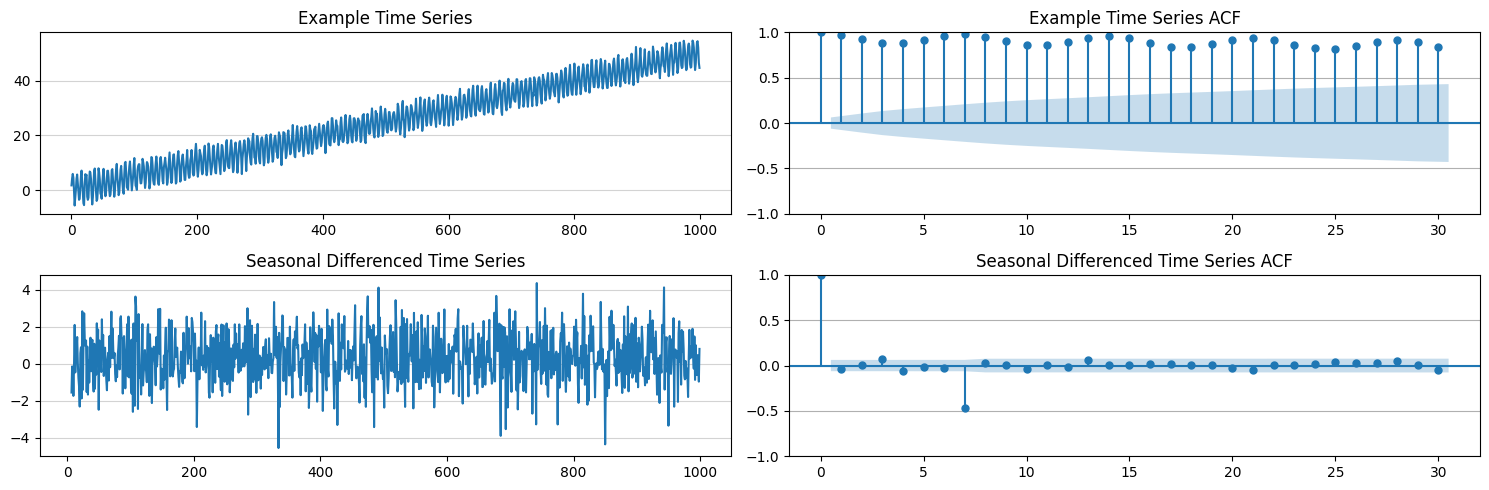

In [19]:
# Example 8: Seasonal Differencing
# ------------------------------------------------------------------------------

np.random.seed(0)  # For reproducibility

# Given a number of time steps and seasonal periods
n_time_steps = 1000
seasonality = 7
time = np.arange(n_time_steps)

# When we create an additive time series
seasonal_component = 5 * np.sin(2 * np.pi * time / seasonality)
trend = 0.05 * time
random_noise = np.random.normal(0, 1, size=n_time_steps)

time_series = trend + seasonal_component + random_noise

# Then we can take the seasonal difference of the sample time series
time_series = pd.Series(time_series)

# We need to drop the null values in order for us to generate the ACF plot
seasonal_diff = time_series.diff(seasonality).dropna()

fig, ax = plt.subplots(2, 2, figsize=(15, 5))

time_series_collection = [time_series, seasonal_diff]
series_names = ["Example Time Series", "Seasonal Differenced Time Series"]
for i, series in enumerate(time_series_collection):
    ax[i % 2, 0].plot(series)
    ax[i % 2, 0].set_title(series_names[i])
    ax[i % 2, 0].grid(axis="y", c="lightgray")
    plot_acf(series, ax=ax[i % 2, 1], title=f"{series_names[i]} ACF")

plt.tight_layout()

# Mathematical Interlude: Backshift Notation

A useful notaion when talking about ARMA is the backshift operator $\mathbf{B}$. In particular, it operates on $y_t$ by shifting the data back by one period.

$$\mathbf{B}y_t = y_{t-1}$$

We can use $\mathbf{B}$ repeatedly to shift the data back multiple times. For example

\begin{align*}
    \mathbf{B}(\mathbf{B}y_t) = \mathbf{B}^2y_t = y_{t-2}
\end{align*}

**This notation is convenient when describing the process of differencing** (to be discussed in the next subsection).

In general, we can define a $d\text{th}$-order difference as

\begin{equation}
(1 - \mathbf{B})^dy_t
\end{equation}

---

**Example Proof**

To see how this works, let's try to take the 2nd-order difference of $y_t$. We can denote this second difference as $y_t''$. Consequently, the first difference is defined as $y_t' = y_t - y_{t - 1}$. From this we define the second difference as

\begin{align*}
y_t'' &= y_t' - y_{t-1}'\\
      &= (y_t - y_{t - 1}) - (y_{t-1} - y_{t-2})\\
      &= y_t - 2y_{t-1} - y_{t-2}\\
\text{since}\ y_{t-1} = \mathbf{B}y_t \ \text{and} \ y_{t-2} = \mathbf{B}^2y_t\\
y_t'' &= y_t - 2\mathbf{B}y_t + \mathbf{B}^2y_t\\
      &= (1 - 2\mathbf{B} + \mathbf{B}^2)y_t\\
\therefore y_t''  &= (1 - \mathbf{B})^2y_t
\end{align*}

---

The notation's convenience can be further seen by combining differences. Suppose we conduct a seasonal difference followed by a first-order difference. This can be simply written as

$$(1 - \mathbf{B})(1 - \mathbf{B}^m)y_t = (1 - \mathbf{B} - \mathbf{B}^m + \mathbf{B}^{m + 1})y_t$$

This is ultimately equal to $y_t - y_{t-1} - y_{t - m} + y_{t - m - 1}$.

# ARMA

In [21]:
from statsmodels.tsa.arima_process import ArmaProcess

Now that we have the pre-requisites out of the way, let's now discuss an important time series model called the ARMA model. We can think of this model as having two parts:

1. AR: Autoregression; and
2. MA: Moving Average

We will discuss both components individually and we can derive how we could combine these two models.

## Autoregression (AR)

In an autoregression model, we generate our forecasts based on a *linear combination* of past values of our target variable. The term *autoregression* means that it is a regression of the variable against itself. An autoregressive model of order $p$, denoted as $\text{AR}(p)$, can be written as

$$y_t = c + \phi_1y_{t-1} + \dots + \phi_py_{t-p} + \epsilon_t$$

where $c$ is a constant and $\epsilon_t$ is white noise. Using the backshift operator $\mathbf{B}$ we can rewrite it as

\begin{align*}
y_t &=c + \phi_1\mathbf{B}y_t + \dots + \phi_p\mathbf{B}^py_t + \epsilon_t \\
y_t    &=c + \left(\sum_{i=1}^p\phi_i\mathbf{B}^i\right)y_t + \epsilon_t
\end{align*}

There are some interesting properties with an $\text{AR}(1)$ model defined as

$$y_t = c + \phi_1y_{t-1} + \epsilon_t$$

- when $\phi_1 = 0$ and $c=0$, then it is equivalent to white noise: $y_t = \epsilon_t$
- when $\phi_1 = 1$ and $c=0$, then it is a random walk: $y_t = y_{t-1} + \epsilon_t$
- when $\phi_1 = 1$ and $c\neq0$, then it is a random walk with drift: $y_t = c + y_{t-1} + \epsilon_t$
- when $\phi_1 < 0$, then $y_t$ tends to oscillate around the mean. Since each $y_t$ would be the opposite of $y_{t-1}$
 

In [22]:
# Let's create an AR(1) model and validate the properties above with a dataset
def ar1_model(
    time_series: Union[list, np.ndarray],
    phi: Union[int, float],
    constant: Optional[Union[int, float]] = 0,
):
    n_points = len(time_series)
    results = np.zeros(n_points)
    results[0] = time_series[0]
    white_noise = np.random.normal(0, 1, size=n_points)
    for i in range(1, n_points):
        results[i] = constant + phi * results[i - 1] + white_noise[i]
    return results

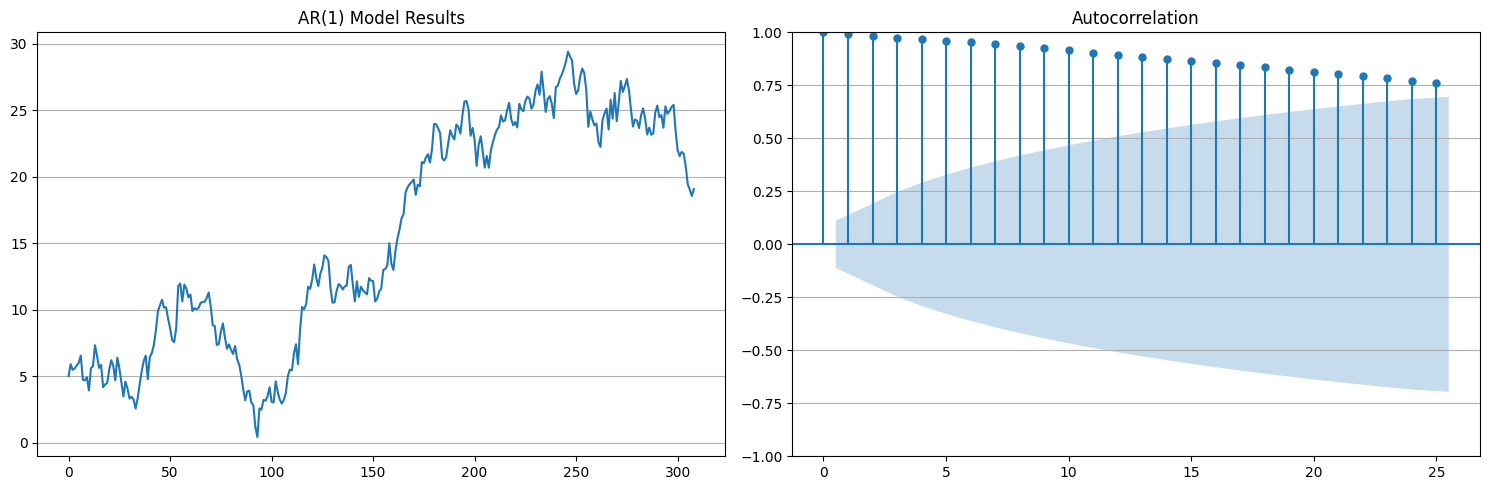

In [23]:
# Example 9: AR(1) Model
# ------------------------------------------------------------------------------

# Given a time series data and defined values
sunspots_data = sm.datasets.sunspots.load_pandas().data

# ---------Adjust These Values---------
phi = 1
constant = 0
# ---------Adjust These Values---------

# When creating an AR(1) model from the given data
ar1_results = ar1_model(sunspots_data["SUNACTIVITY"].values, phi=phi, constant=constant)

# Then we can view the properties of the AR(1) model based on the defined values
fig, ax = plt.subplots(1, 2)

ax[0].plot(ar1_results)
plot_acf(ar1_results, ax=ax[1])
ax[0].set_title("AR(1) Model Results")
plt.tight_layout()


## Moving Average (MA)

Compared to an autoregression model, moving average models use the **past forecast errors** in a regression-like fashion. A standard moving average model of order *q*, denoted as $\text{MA}(q)$, is defined as 

$$y_t = c + \epsilon_t + \theta_1\epsilon_{t-1} + \dots + \theta_q\epsilon_{t-q},$$

where $\epsilon_t$ is white noise. We do not necessarily observe $\epsilon_t$ so it is *not* a regression in the usual sense. Using the backshift operator $\mathbf{B}$ we can rewrite this as

$$y_t = c + \left(1 + \sum_{i=1}^q\theta_i\mathbf{B}^i\right)\epsilon_t$$

It should be noted that a moving average model is different from a moving average smoothing. This smoothing method is commonly used to estimate the trend-cycle pattern in a series by getting a rolling average. The moving average model, on the other hand, is used for forecasting future values by using the errors. 

You may notice that the $\text{AR}(p)$ model seems to share some similarities with $\text{MA}(q)$. It is possible to write any stationary $\text{AR}(p)$ process as an $\text{MA}(\infty)$ model. The reverse holds true if we impose some constraints on $\text{MA}(q)$ parameters. In this manner, we call this model as **invertible**.

We can define an $\text{MA}(1)$ model as

$$y_t = c + \epsilon_t + \theta_1\epsilon_{t-1}$$

In [24]:
# Let's create an MA(1) model and validate the properties above with a dataset
def ma1_model(
    n_points: int, theta: Union[int, float], constant: Optional[Union[int, float]] = 0
):
    moving_average = np.zeros(n_points)
    white_noise = np.random.normal(0, 1, size=n_points)

    moving_average[0] = constant + white_noise[0]
    for i in range(1, n_points):
        moving_average[i] = constant + white_noise[i] + theta * white_noise[i - 1]
    return moving_average

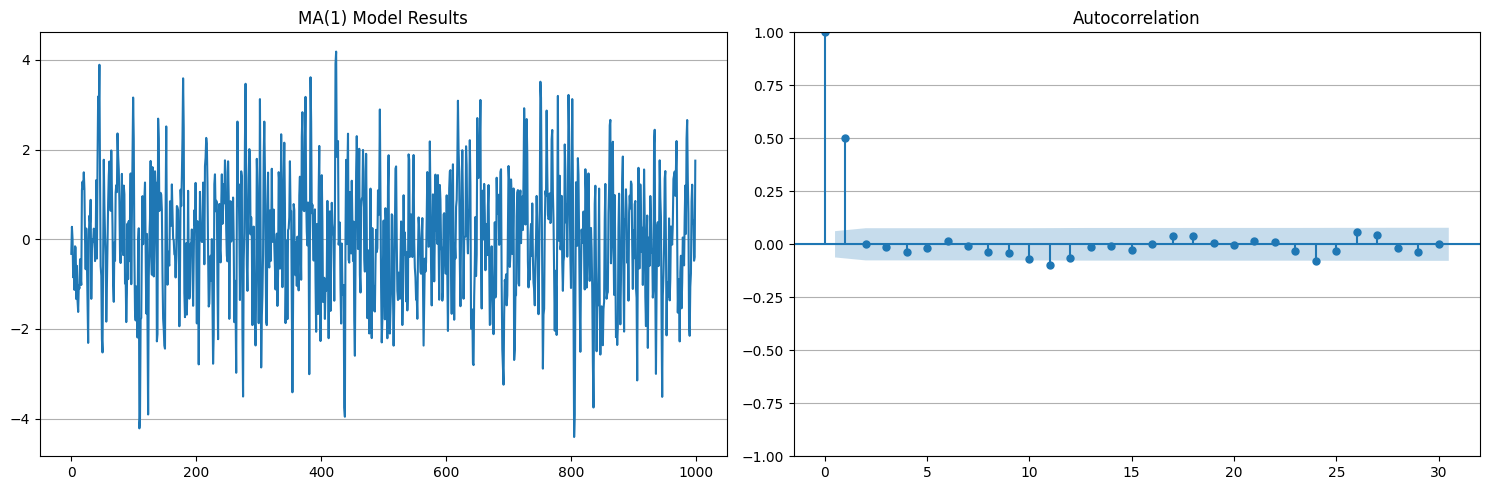

In [25]:
# Example 10: MA(1) Model
# To illustrate how the moving average model works, let's do a simple MA(1) model
# The process is similar to our AR(1) model from Example 9
# ------------------------------------------------------------------------------

# Given a time series data and defined values
n_points = 1000

# ---------Adjust These Values---------
constant = 0
theta = 1
# ---------Adjust These Values---------

# When creating an MA(1) model from the given data
ma1_results = ma1_model(n_points, theta=theta, constant=constant)

# Then we can view the properties of the MA(1) model based on the defined values
fig, ax = plt.subplots(1, 2)

ax[0].plot(ma1_results)
plot_acf(ma1_results, ax=ax[1])
ax[0].set_title("MA(1) Model Results")
plt.tight_layout()


### Revisiting the Unit Root

An important concept to learn about time series data is the *unit root*. A unit root basically hinders us from using our ARMA model, because it causes our time series to be **non-stationary**. 

To properly use our AR, MA, and ARMA models we need to process our time series in such a way that it removes the unit root. This can be done using differencing or other methods. Even if we can't remove the unit root, being aware that this is present can help guide us to use different methods. 

To understand unit roots, let's look at our $\text{AR}(1)$ model. For convenience, let's set $c=0$

$$y_t = \phi y_{t-1} + \epsilon_t$$
 

When we talk about unit roots, what we're really talking about is the value of $\phi$ here. Let's expand our model further and try to reach a condition on *time series invertibility*. We won't discuss that for now, so I'll provide the math concept.

\begin{align*}
\text{We start with our AR(1) model}\\
y_t &= \phi y_{t-1} + \epsilon_t\\
\text{We can argue that}\\
y_{t-1} &= \phi y_{t-2} + \epsilon_{t-1}\\
\text{Therefore,}\\
y_t &= \phi (\phi y_{t-2} + \epsilon_{t-1}) + \epsilon_t\\
y_t &= \phi^2 y_{t-2} + \phi \epsilon_{t-1} + \epsilon_t\\
\text{We can keep doing this for } k \text{ lags. We would eventually get}\\
y_t &= \phi^ky_{t-k} + \sum_{i=0}^{k-1}\phi^i\epsilon_{t-i}\\
\text{As } k \rightarrow t, \text{ we get}\\
y_t &= \phi^ty_{0} + \sum_{i=0}^{t-1}\phi^i\epsilon_{t-i}\\
\end{align*}

Okay, now why does this matter?

It matters because if $|\phi| < 1$, we find that $\phi^ty_0 \rightarrow 0$ as $t \rightarrow 0$. Eventually we find that our $\text{AR(1)}$ can be represented as an $\text{MA}(\infty)$ model. 

If $|\phi| < 1$, then

$$y_t = \sum_{i=0}^{t-1}\phi^i\epsilon_{t-i}$$

which we find that we eventually encounter to have a constant mean and variance, and a finite variance.


If $|\phi| > 1$, then our $\text{AR}(1)$ model explodes. As $t \rightarrow \infty$, $\phi^t$ diverges. 


If $|\phi| = 1$, then we get a random walk. Specifically, from the $\text{AR}(1)$ model
$$y_t = y_{t-1} + \epsilon_t$$

where the mean may be constant, but the variance can change. 

Ideally, we want our roots to be $|\phi| < 1$ or our roots lying within a unit circle. If this condition has been met, then we can say that our time series is stationary.

## Unifying $\text{AR}(p)$ and $\text{MA}(q)$

We can combine both autoregressive and moving average models into a single ARMA model. This models has its own characteristics, but we can provide a simple derivation through the following: 


\begin{align*}
\text{ARMA}(p, q): y_t &= \text{AR}(p) + \text{MA}(q)\\
                  &= \left[c + \left(\sum_{i=1}^p\phi_i\mathbf{B}^i \right)y_t + \epsilon_t \right] + \left[c + \left(1 + \sum_{i=1}^q\theta_i\mathbf{B}^i\right)\epsilon_t \right]\\
                  &= 2c + \left(\sum_{i=1}^p\phi_i\mathbf{B}^i \right)y_t + \left(1 + \sum_{i=1}^q\theta_i\mathbf{B}^i\right)\epsilon_t + \epsilon_t\\
                  &= 2c + 2\epsilon_t + \left(\sum_{i=1}^i\phi_i\mathbf{B}^i \right)y_t + \left(\sum_{i=1}^q\theta_i\mathbf{B}^i\right)\epsilon_t\\
&\text{Since ARMA unifies both models, the constants and noise are the same for the entire model } C = 2c; \ \zeta_t = 2\epsilon_t\\
                  &= C + \zeta_t + \left(\sum_{i=1}^p\phi_i\mathbf{B}^i \right)y_t + \left(\sum_{i=1}^q\theta_i\mathbf{B}^i\right)\epsilon_t\\
                  & \text{Simplifying everything we get}\\
                 \text{ARMA}(p, q): y_t &= C + \zeta_t + \sum_{i=1}^p\phi_iy_{t-i} + \sum_{i=1}^q\theta_i\epsilon_{t-i}\\
\end{align*}

# Metrics

We introduce a couple of new metrics for time series forecasting. Given that we have $n$ points, we can measure our model's accuracy by optimizing for any of these metrics. Provided we have the $i$-th predicted value $y_i$ and the $i$-th true $x_i$, I leave it up to you to study these metrics.

\begin{align*}
\text{Mean Absolute Error (MAE)} &= \frac{1}{n}\sum_{i=1}^n|y_i - x_i|\\
\text{Mean Squared Error (MSE)} &= \frac{1}{n}\sum_{i=1}^n(x_i - y_i)^2\\
\text{Root Mean Squared Error (RMSE)} &= \sqrt{\text{MSE}}\\
\text{Mean Absolute Percentage Error (MAPE)} &= \frac{1}{n}\sum_{i=1}^n\left|\frac{x_i - y_i}{x_i}\right| \times 100\\
\text{Symmetric Mean Absolute Percentage Error (SMAPE)} &= \frac{1}{n}\sum_{i=1}^n\frac{|x_i - y_i|}{(|x_i| + |y_i|) / 2} \times 100\\
\end{align*}

# References

[1] Chapter 1 Getting started | Forecasting: Principles and Practice (3rd ed). (n.d.). https://otexts.com/fpp3/intro.html <br>
[2] GeeksforGeeks. (2025, July 23). Understanding Partial Autocorrelation Functions (PACF) in time series data. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/understanding-partial-autocorrelation-functions-pacf-in-time-series-data/ <br>
[3] Vijay. (2025, April 4). Understanding Stationary Time series analysis. Analytics Vidhya. https://www.analyticsvidhya.com/blog/2021/06/statistical-tests-to-check-stationarity-in-time-series-part-1/